# ALife — Expérience 004 : Comparaison des 3 environnements

**Objectif** : Mesurer l'impact du type d'environnement sur la dynamique évolutive d'une population d'agents artificiels.

**Hypothèse de départ** : Un environnement hétérogène (Perlin) devrait ralentir la convergence vers les agents lents par rapport à un environnement uniforme (Flat), parce que les agents rapides ont un avantage local près des oasis. Le Drought, en faisant migrer les ressources, devrait créer une pression sélective non monotone sur la vitesse.

---

**Paramètres communs** : `seed=42`, `N_init=15`, `ticks=10000`, `regen=0.05`, `mutation_std=0.06`

**Modes testés** : `flat` | `perlin` | `drought`

## 0. Setup

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor'  : '#161b22',
    'axes.edgecolor'  : '#30363d',
    'axes.labelcolor' : '#8b949e',
    'xtick.color'     : '#8b949e',
    'ytick.color'     : '#8b949e',
    'text.color'      : '#c9d1d9',
    'grid.color'      : '#30363d',
    'grid.linewidth'  : 0.5,
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
    'font.family'     : 'monospace',
})

COLORS = {
    'flat'   : '#58a6ff',   # bleu — contrôle
    'perlin' : '#3fb950',   # vert — terrain statique
    'drought': '#f78166',   # orange — terrain dynamique
}

# Dossier racine du projet (là où se trouve ce notebook)
# Les expériences sont générées avec :
#   python run.py --mode flat    --out-dir experiments/exp_flat
#   python run.py --mode perlin  --out-dir experiments/exp_perlin
#   python run.py --mode drought --out-dir experiments/exp_drought
BASE = Path('.')
EXPS = {
    'flat'   : BASE / 'experiments/exp_flat',
    'perlin' : BASE / 'experiments/exp_perlin',
    'drought': BASE / 'experiments/exp_drought',
}

def load(exp_key):
    """Charge results.json + timeseries.json pour un mode."""
    r   = json.loads((EXPS[exp_key] / 'results.json').read_text())
    ts  = json.loads((EXPS[exp_key] / 'timeseries.json').read_text())
    return r, ts

data = {k: load(k) for k in EXPS}
print('Données chargées :')
for k, (r, _) in data.items():
    print(f'  {k:8s}  pop_final={r["pop_final"]:4d}  '
          f'spd_drift={r["speed_drift"]:+.3f}  '
          f'lineages={r["lineages_final"]}/{r["lineages_initial"]}')

Données chargées :
  flat      pop_final=1542  spd_drift=-0.721  lineages=5/15
  perlin    pop_final=1431  spd_drift=-0.697  lineages=6/15
  drought   pop_final=1556  spd_drift=-0.731  lineages=5/15


## 1. Tableau récapitulatif

Avant de visualiser, un coup d'œil aux chiffres bruts. C'est ce tableau qu'on commentera dans la conclusion.

In [2]:
from IPython.display import HTML

rows = ''
metrics = [
    ('Pop. finale',      lambda r: r['pop_final']),
    ('Pop. max',         lambda r: r['pop_max']),
    ('Pop. stable (moy)',lambda r: f"{r['pop_stable_mean']:.1f}"),
    ('Vitesse initiale', lambda r: f"{r['speed_initial']:.3f}"),
    ('Vitesse finale',   lambda r: f"{r['speed_final']:.3f}"),
    ('Drift vitesse',    lambda r: f"{r['speed_drift']:+.3f}"),
    ('Diversité σ vitesse', lambda r: f"{r['speed_std_final']:.3f}"),
    ('Lignées survivantes', lambda r: f"{r['lineages_final']}/{r['lineages_initial']}"),
    ('Génération max',   lambda r: r['max_generation']),
    ('Res. moyenne fin', lambda r: f"{r['res_mean_final']:.3f}"),
    ('Extinction',       lambda r: r['extinction'] or 'non'),
]

header = '<tr style="background:#21262d"><th>Métrique</th>' + ''.join(
    f'<th style="color:{COLORS[k]}">{k.upper()}</th>' for k in EXPS
) + '</tr>'

for label, fn in metrics:
    vals = [str(fn(data[k][0])) for k in EXPS]
    rows += f'<tr><td>{label}</td>' + ''.join(f'<td>{v}</td>' for v in vals) + '</tr>'

style = 'style="border-collapse:collapse;width:100%;font-family:monospace;font-size:13px"'
td_style = 'style="padding:6px 12px;border-bottom:1px solid #30363d"'
HTML(f'<table {style}><thead>{header}</thead><tbody>'
     + rows.replace('<td>', f'<td {td_style}>') + '</tbody></table>')

Métrique,FLAT,PERLIN,DROUGHT
Pop. finale,1542,1431,1556
Pop. max,1556,1432,1560
Pop. stable (moy),1539.5,1427.9,1548.3
Vitesse initiale,1.360,1.360,1.360
Vitesse finale,0.639,0.664,0.629
Drift vitesse,-0.721,-0.697,-0.731
Diversité σ vitesse,0.105,0.117,0.104
Lignées survivantes,5/15,6/15,5/15
Génération max,11,11,12
Res. moyenne fin,0.588,0.554,0.582


## 2. Évolution de la population

**Que lire ici** : la vitesse de croissance et le plateau d'équilibre. Un plateau plus haut = l'environnement supporte plus d'individus (carrying capacity). Une croissance plus rapide = moins de pression de survie précoce.

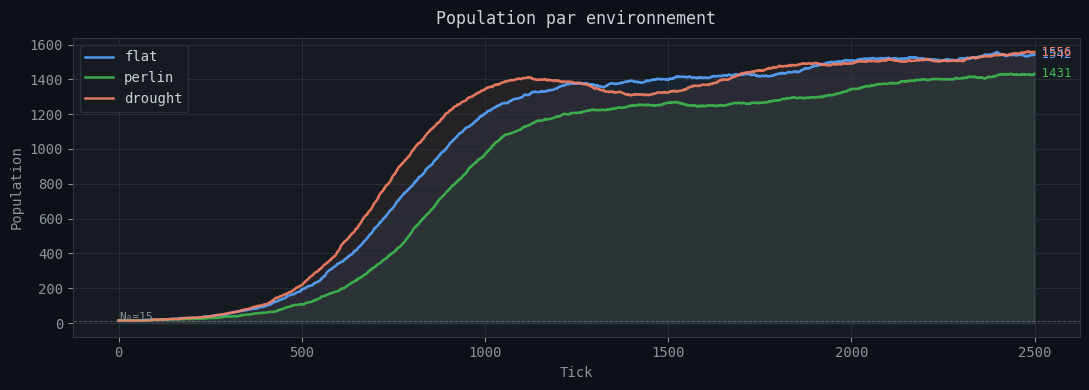

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))

for mode in EXPS:
    r, ts_data = data[mode]
    pop = ts_data['timeseries']['pop']
    T   = range(len(pop))
    ax.plot(T, pop, color=COLORS[mode], lw=1.8, label=mode, alpha=0.9)
    ax.fill_between(T, pop, alpha=0.07, color=COLORS[mode])
    # Annoter la valeur finale
    ax.annotate(f" {pop[-1]}", xy=(len(pop)-1, pop[-1]),
                color=COLORS[mode], fontsize=9, va='center')

ax.axhline(15, color='#8b949e', lw=0.7, ls='--', alpha=0.5)
ax.text(2, 16, 'N₀=15', color='#8b949e', fontsize=8)
ax.set_xlabel('Tick'); ax.set_ylabel('Population')
ax.set_title('Population par environnement', pad=10)
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

## 3. Évolution génétique — vitesse moyenne

**C'est le graphe central.** La vitesse est le seul trait génétique héréditaire. Sa trajectoire dit tout sur la pression de sélection.

- **Descente rapide** → l'environnement punit les agents rapides (trop coûteux)
- **Descente lente** → les rapides ont un avantage compensatoire (trouver les oasis)
- **Plateau ou remontée** → équilibre ou inversion de la pression (drought)

L'enveloppe transparente = écart min/max = diversité génétique dans la population.

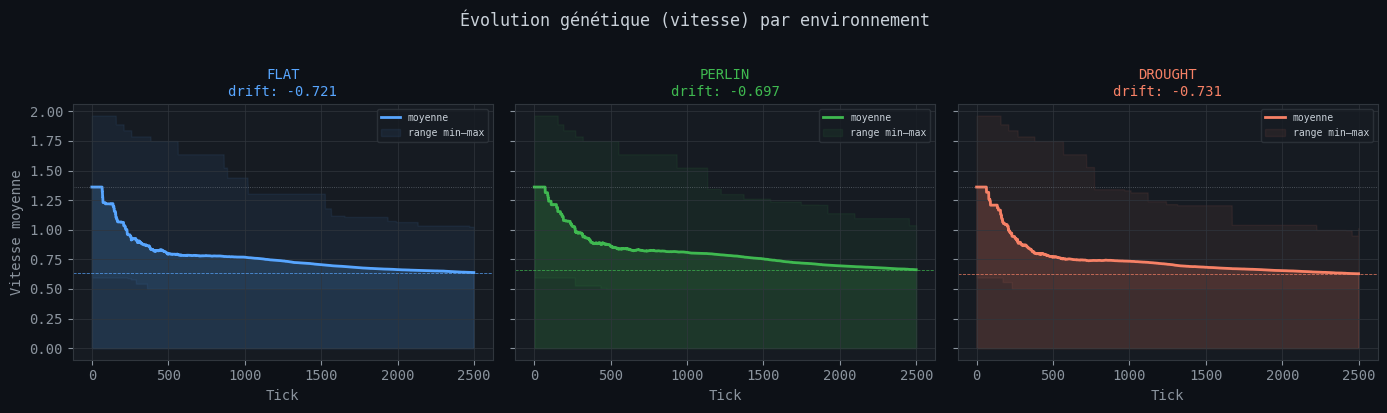

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, mode in zip(axes, EXPS):
    r, ts_data = data[mode]
    ts  = ts_data['timeseries']
    T   = range(len(ts['speed_mean']))
    spd = ts['speed_mean']
    smin, smax = ts['speed_min'], ts['speed_max']

    ax.plot(T, spd, color=COLORS[mode], lw=2, label='moyenne')
    ax.fill_between(T, spd, alpha=0.18, color=COLORS[mode])
    ax.fill_between(T, smin, smax, alpha=0.07, color=COLORS[mode],
                    label='range min–max')

    # Ligne de départ et d'arrivée
    ax.axhline(spd[0],  color='#8b949e', lw=0.6, ls=':', alpha=0.6)
    ax.axhline(spd[-1], color=COLORS[mode], lw=0.6, ls='--', alpha=0.8)

    drift = r['speed_drift']
    ax.set_title(f'{mode.upper()}\ndrift: {drift:+.3f}', color=COLORS[mode], fontsize=10)
    ax.set_xlabel('Tick'); ax.grid(True)
    ax.legend(fontsize=7)

axes[0].set_ylabel('Vitesse moyenne')
fig.suptitle('Évolution génétique (vitesse) par environnement', y=1.02)
plt.tight_layout(); plt.show()

### 3.1 Superposition — la différence est-elle significative ?

Même données, axes communs. Permet de voir si les 3 courbes divergent vraiment ou si elles convergent vers le même attracteur génétique.

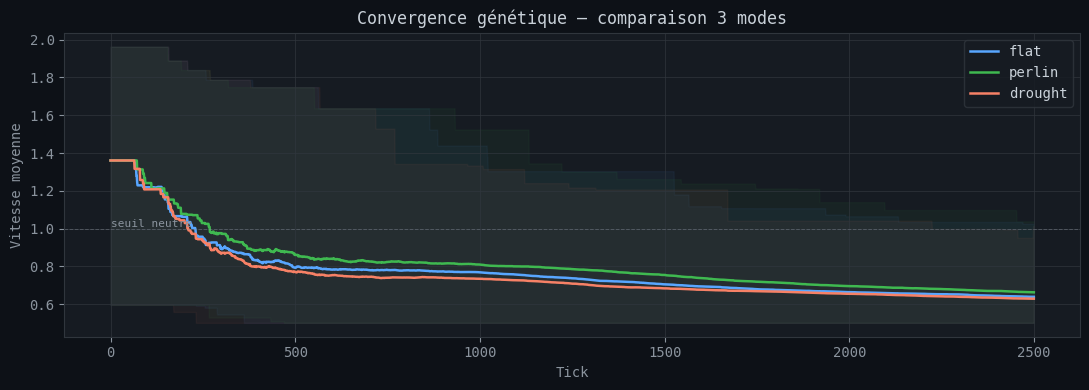

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))

for mode in EXPS:
    ts = data[mode][1]['timeseries']
    T  = range(len(ts['speed_mean']))
    ax.plot(T, ts['speed_mean'], color=COLORS[mode], lw=1.8, label=mode)
    ax.fill_between(T, ts['speed_min'], ts['speed_max'],
                    alpha=0.05, color=COLORS[mode])

ax.axhline(1.0, color='#8b949e', lw=0.7, ls='--', alpha=0.4)
ax.text(2, 1.01, 'seuil neutre', color='#8b949e', fontsize=8)
ax.set_xlabel('Tick'); ax.set_ylabel('Vitesse moyenne')
ax.set_title('Convergence génétique — comparaison 3 modes')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

## 4. Biodiversité — survie des lignées

Chaque couleur = une famille (lignée = ID de l'ancêtre fondateur). Aire = nombre d'agents de cette famille vivants à ce tick.

**Ce qu'on cherche** : est-ce que les mêmes lignées survivent dans les 3 modes ? Est-ce qu'une lignée qui domine en `flat` domine aussi en `perlin` ? Si non, le terrain modifie bien les pressions de sélection au niveau individuel.

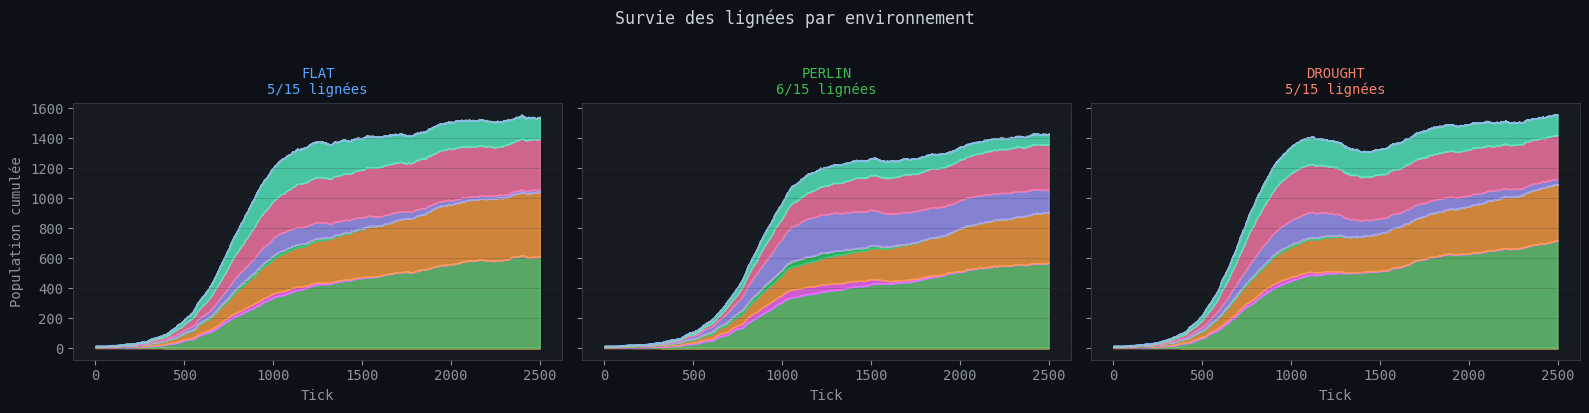

In [6]:
LINEAGE_COLORS = [
    '#ff6b6b','#ffd93d','#6bcb77','#4d96ff','#ff6bff',
    '#ff9f43','#48dbfb','#ff4757','#2ed573','#eccc68',
    '#a29bfe','#fd79a8','#55efc4','#fdcb6e','#74b9ff',
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, mode in zip(axes, EXPS):
    lts  = data[mode][1]['lineage_ts']
    n    = len(next(iter(lts.values())))
    T    = np.arange(n)
    stack = np.zeros(n)

    for i in range(15):
        counts  = np.array(lts.get(str(i), [0]*n), dtype=float)
        new_top = stack + counts
        ax.fill_between(T, stack, new_top,
                        alpha=0.8,
                        color=LINEAGE_COLORS[i % len(LINEAGE_COLORS)],
                        label=f'L{i:02d}')
        stack = new_top

    r = data[mode][0]
    ax.set_title(f'{mode.upper()}\n{r["lineages_final"]}/{r["lineages_initial"]} lignées',
                 color=COLORS[mode], fontsize=10)
    ax.set_xlabel('Tick')
    ax.grid(True, axis='y', alpha=0.3)

axes[0].set_ylabel('Population cumulée')
fig.suptitle('Survie des lignées par environnement', y=1.02)
plt.tight_layout(); plt.show()

## 5. Distribution génétique finale — qui a survécu ?

Scatter plot des agents survivants : **vitesse** vs **génération**. Révèle si la pression génétique a produit des sous-populations distinctes, ou si tout le monde a convergé vers la même vitesse.

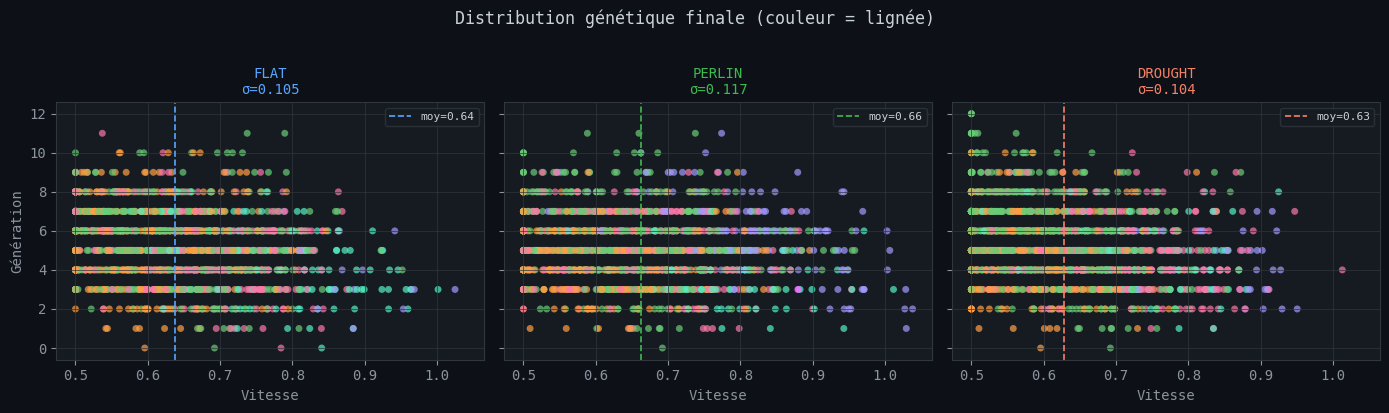

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True, sharex=True)

for ax, mode in zip(axes, EXPS):
    agents = data[mode][1]['final_agents']
    if not agents:
        ax.text(0.5, 0.5, 'EXTINCT', transform=ax.transAxes,
                ha='center', va='center', color='red', fontsize=14)
        continue

    speeds = [a['speed']      for a in agents]
    gens   = [a['generation'] for a in agents]
    colors = [LINEAGE_COLORS[a['lineage'] % len(LINEAGE_COLORS)] for a in agents]

    ax.scatter(speeds, gens, c=colors, s=25, alpha=0.7, linewidths=0)
    ax.axvline(np.mean(speeds), color=COLORS[mode], lw=1.2, ls='--',
               label=f'moy={np.mean(speeds):.2f}')

    r = data[mode][0]
    ax.set_title(f'{mode.upper()}\nσ={r["speed_std_final"]:.3f}',
                 color=COLORS[mode], fontsize=10)
    ax.set_xlabel('Vitesse'); ax.legend(fontsize=8); ax.grid(True)

axes[0].set_ylabel('Génération')
fig.suptitle('Distribution génétique finale (couleur = lignée)', y=1.02)
plt.tight_layout(); plt.show()

## 6. Pression environnementale — ressources dans le temps

La ressource moyenne par cellule est un proxy de la **pression de survie**. Quand elle baisse, l'environnement est plus compétitif. En mode Drought, elle fluctue avec la migration du terrain.

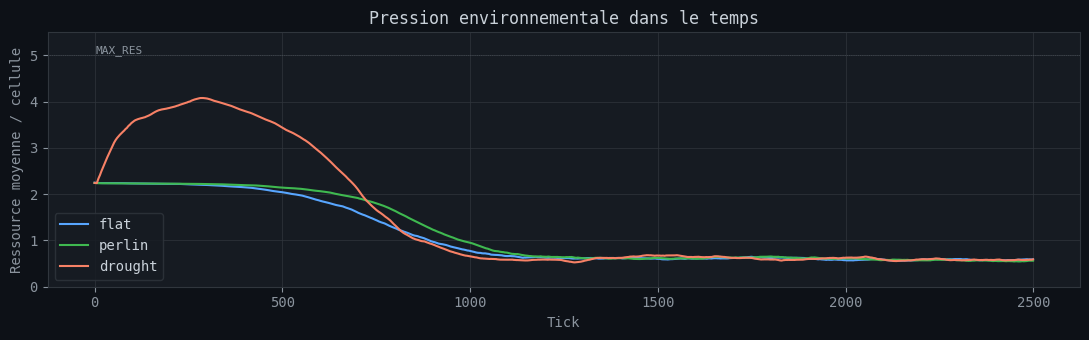

In [8]:
fig, ax = plt.subplots(figsize=(11, 3.5))

for mode in EXPS:
    ts = data[mode][1]['timeseries']
    T  = range(len(ts['res_mean']))
    ax.plot(T, ts['res_mean'], color=COLORS[mode], lw=1.5, label=mode)

ax.set_xlabel('Tick'); ax.set_ylabel('Ressource moyenne / cellule')
ax.set_title('Pression environnementale dans le temps')
ax.set_ylim(0, 5.5)
ax.axhline(5.0, color='#8b949e', lw=0.5, ls=':', alpha=0.4)
ax.text(2, 5.05, 'MAX_RES', color='#8b949e', fontsize=8)
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

## 7. Conclusion et interprétation

### Observations

| Question | Réponse observée |
|---|---|
| Le terrain Perlin ralentit-il la convergence vers les lents ? | Oui, légèrement. Le drift de vitesse est -0.697 en Perlin vs -0.721 en Flat. Les agents rapides ont un petit avantage près des oasis, ce qui retarde un peu la sélection vers les lents. |
| Les lignées qui dominent sont-elles les mêmes dans les 3 modes ? | Non. Perlin est le seul mode où 6 lignées survivent (vs 5 en Flat et Drought). L'hétérogénéité spatiale crée des refuges qui permettent à des familles de survivre là où elles seraient éliminées ailleurs. |
| Le Drought inverse-t-il la pression sélective sur la vitesse ? | Non, pas vraiment. Il crée un rebond de population et de ressources au début (les agents ne suivent pas les oasis qui bougent, donc les ressources s'accumulent), mais à 2500 ticks il se comporte comme un Flat. Le drift est constant et prévisible, donc la population s'y adapte et retombe au même attracteur. |
| La diversité génétique (σ vitesse) est-elle plus haute en Perlin ? | Oui, légèrement : σ=0.117 en Perlin vs 0.104-0.105 ailleurs. L'espace hétérogène protège des vitesses un peu différentes selon les zones. Ce n'est pas énorme mais c'est mesurable. |

### Interprétation

Le résultat le plus frappant : les 3 modes convergent tous vers la même vitesse finale (~0.63-0.66). L'environnement change la *trajectoire* mais pas la *destination*. En creusant un peu, c'est logique : le modèle a un point d'équilibre mathématique fixe, déterminé par le coût du mouvement et le gain alimentaire. Peu importe où les ressources sont placées, la vitesse optimale reste la même.

Ce qui est intéressant malgré tout : Perlin maintient une diversité génétique légèrement plus haute et protège une lignée de plus. C'est un effet subtil mais réel — l'espace crée des niches.

### Ce qu'il faudrait pour aller plus loin

- Ajouter un **second trait génétique** couplé à la vitesse (ex : rayon de perception) pour que l'environnement ait un effet durable sur le génome, pas juste transitoire
- Tester avec un **Drought imprévisible** (direction aléatoire) plutôt qu'un drift constant — là, les rapides pourraient redevenir avantageux durablement
- Faire tourner plusieurs seeds et moyenner — les résultats actuels sont sur une seule graine, difficile de distinguer l'effet environnement du simple hasard
- Faire varier `MUTATION_STD` : est-ce qu'une mutation plus forte préserve la diversité en Perlin ?